
Benchmarking ECDSA Signature Algorithm (Curve: secp384r1)
Running 100 iterations for benchmarking...


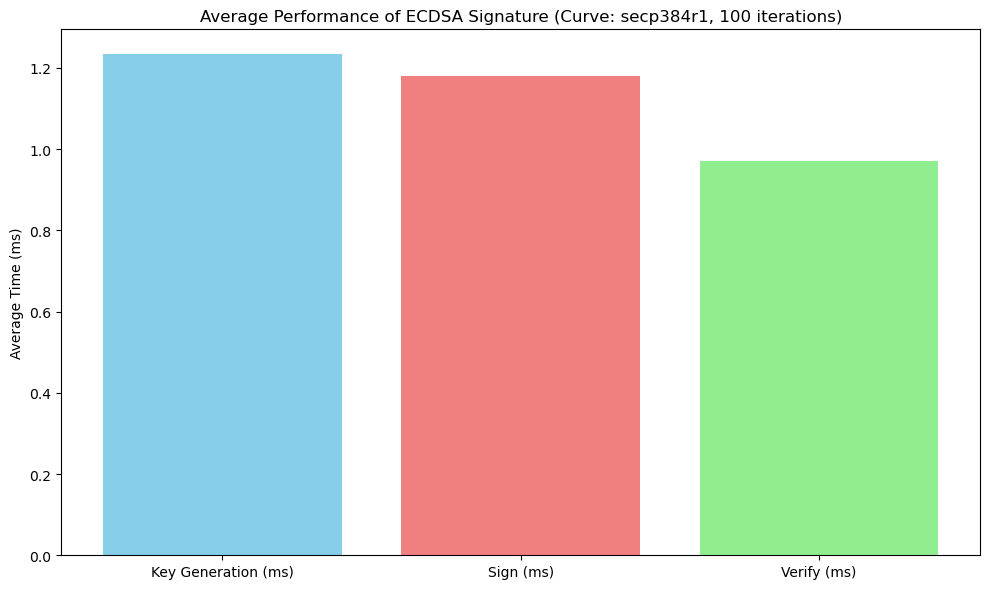


--- Benchmark Results ---
Algorithm: ECDSA (Curve: secp384r1)
Iterations: 100
Average Key Generation Time: 1.2331 ms
Average Sign Time:     1.1810 ms
Average Verify Time:   0.9717 ms

Overall verification success during benchmark: True


In [1]:
import logging
from pprint import pformat
from sys import stdout
import time  # Import the time module for benchmarking
import statistics  # Import statistics for calculating mean
import matplotlib.pyplot as plt  # Import matplotlib

from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import ec
from cryptography.hazmat.primitives.asymmetric import utils
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(stdout))

message = b"This is the message to sign" * 10  # Make message slightly longer

# Choose an ECDSA curve with security comparable to AES-256
ecdsa_curve = ec.SECP384R1()  # Using a 384-bit curve

logger.info(f"\nBenchmarking ECDSA Signature Algorithm (Curve: {ecdsa_curve.name})")

# Number of iterations for benchmarking
N_ITERATIONS = 100  # You might adjust this based on performance
logger.info(f"Running {N_ITERATIONS} iterations for benchmarking...")

# Lists to store timings
keygen_times = []
sign_times = []
verify_times = []

# --- Benchmarking Loop ---
all_valid = True  # Flag to track if all verifications passed
for i in range(N_ITERATIONS):
    try:
        # 1. Benchmark Key Generation
        start_time = time.perf_counter()
        private_key = ec.generate_private_key(ecdsa_curve, default_backend())
        public_key = private_key.public_key()
        end_time = time.perf_counter()
        keygen_times.append(end_time - start_time)

        # 2. Benchmark Signing
        start_time = time.perf_counter()
        signature = private_key.sign(message, ec.ECDSA(hashes.SHA256()))
        end_time = time.perf_counter()
        sign_times.append(end_time - start_time)

        # 3. Benchmark Verification
        start_time = time.perf_counter()
        try:
            public_key.verify(signature, message, ec.ECDSA(hashes.SHA256()))
            is_valid = True
        except utils.InvalidSignature:
            is_valid = False
        end_time = time.perf_counter()
        verify_times.append(end_time - start_time)

        if not is_valid:
            logger.warning(f"Signature verification failed during iteration {i+1}!")
            all_valid = False
            # Decide if you want to break or continue benchmarking
            # break

    except Exception as e:
        logger.error(f"An error occurred during benchmarking: {e}")
        # Clear lists as benchmark couldn't complete reliably
        keygen_times, sign_times, verify_times = [], [], []
        all_valid = False
        break  # Exit the loop

# Check if benchmarking actually ran
if not keygen_times:
    logger.error("Benchmarking could not be performed.")
else:
    # --- Calculate and Print Results ---
    avg_keygen_ms = statistics.mean(keygen_times) * 1000
    avg_sign_ms = statistics.mean(sign_times) * 1000
    avg_verify_ms = statistics.mean(verify_times) * 1000

    # --- Generate the Graph ---
    labels = ['Key Generation (ms)', 'Sign (ms)', 'Verify (ms)']
    times = [avg_keygen_ms, avg_sign_ms, avg_verify_ms]
    colors = ['skyblue', 'lightcoral', 'lightgreen']

    plt.figure(figsize=(10, 6))
    plt.bar(labels, times, color=colors)
    plt.ylabel("Average Time (ms)")
    plt.title(f"Average Performance of ECDSA Signature (Curve: {ecdsa_curve.name}, {N_ITERATIONS} iterations)")
    plt.xticks(labels)
    plt.tight_layout()
    plt.show()

    # --- Print Text Results ---
    logger.info("\n--- Benchmark Results ---")
    logger.info(f"Algorithm: ECDSA (Curve: {ecdsa_curve.name})")
    logger.info(f"Iterations: {N_ITERATIONS}")
    logger.info(f"Average Key Generation Time: {avg_keygen_ms:.4f} ms")
    logger.info(f"Average Sign Time:     {avg_sign_ms:.4f} ms")
    logger.info(f"Average Verify Time:   {avg_verify_ms:.4f} ms")

    # --- Final Verification Check ---
    logger.info(f"\nOverall verification success during benchmark: {all_valid}")